# Deep Learning

This module shows an example of using a Neural Network to create a predictive model for mortality. The following is the basis for neural network algorithm.

$$\underbrace{\hat{y}}_{\text{Output}} =
\underbrace{g}_{\text{Non-linear activation function}}
\!\left(
\underbrace{w_0}_{\text{Bias}} +
\underbrace{\sum_{i=1}^{m} x_i w_i}_{\text{Linear combination of inputs}}
\right)
$$

There are several types of neural networks and a few listed below. The general process is that there is an input, which has a set of weights and a bias term, that then goes through an activation function (e.g. sigmoid, relu, softmax), which will be the neuron. These then have a loss function that is optimizing the loss. The matrix can be configured depending how deep (number of layers) and wide (number of neurons) the network should be.

- **Feed Forward Neural Network (FFNN)** - This is the simplest type of neural network. 
- **Recurrent Neural Network (RNN)** - Main use is for sequential data. They allow the output of one step to be fed as input into the next step. Some drawbacks of RNN are bottleneck embedding which can be addressed using transformers, no parallelization, no long term memory due to vanishing gradients because the losses are added together for an entire sequence.
- **Convolutional Neural Network (CNN)** - Main use is for image classification, which uses "filters" to identify small important features of a picture which would be used together to form larger interconnected features to classify an image. One caveat is that what the model trains on is what it will expect. For instance, if model only had upright heads in training data, it wouldn't be able to identify a sideways head.

There are some regularlization that can happen as well:
- **Dropout** - removes a percent of activation layers
- **Early Stopping** - stop training before overfitting

If wanting to learn more on neural networks, the following course was helpful:
- https://introtodeeplearning.com/

# Import Modules

In [1]:
import importlib
import os
import sys

import joblib
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
os.chdir("../")
sys.path.insert(0, os.getcwd())

In [3]:
from morai.experience import charters, experience
from morai.forecast import metrics, preprocessors
from morai.models import neural
from morai.utils import custom_logger, helpers

In [4]:
logger = custom_logger.setup_logging(__name__)

In [5]:
# update log level if wanting more logging
custom_logger.set_log_level("INFO")

In [6]:
pd.options.display.float_format = "{:,.2f}".format

In [7]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

Process the data by:

- **Encoding**
  - categorical variables need to be encoded using ordinal, nominal, ohe, embedding
 
- **Feature Engineering**
  - the attained age was split into splines so the neural network was given the structure and would not need to learn from scratch

- **Standardizing**
  - it's helpful for a neural network to have standarized fields to avoid a feature to have too much weight in gradient

- **Splitting**
  - have a test/train split for validation using 20% of the data for testing

In [8]:
pl_parquet_path = r"files/dataset/mortality_grouped.parquet"

In [9]:
# reading in the dataset
# `enable_string_cache` helps with categorical type values
pl.enable_string_cache()
lzdf = pl.scan_parquet(
    pl_parquet_path,
)

In [10]:
initial_row_count = lzdf.select(pl.len()).collect().item()
print(
    f"row count: {initial_row_count:,} \n"
    f"exposures: {lzdf.select([pl.col('amount_exposed').sum()]).collect()[0,0]:,}"
)

row count: 1,522,971 
exposures: 9,054,258,435,620.062


In [11]:
grouped_df = lzdf.collect()

In [12]:
grouped_df = grouped_df.to_pandas()

## Filter

In [13]:
model_data = grouped_df[
    (grouped_df["attained_age"] >= 50)
    # & (grouped_df["attained_age"] <= 95)
    & (grouped_df["issue_age"] >= 30)
    & (grouped_df["issue_age"] <= 80)
].copy()
model_data = model_data.reset_index(drop=True)

In [14]:
del grouped_df

## Calculated Fields

In [15]:
model_data["capped_duration"] = model_data["duration"].clip(upper=26)
model_data["qx_log_raw"] = np.log(model_data["qx_raw"] + 1)
binned_face_dict = {
    "01: 0 - 9,999": "01: 0 - 24,999",
    "02: 10,000 - 24,999": "01: 0 - 24,999",
    "03: 25,000 - 49,999": "02: 25,000 - 99,999",
    "04: 50,000 - 99,999": "02: 25,000 - 99,999",
    "05: 100,000 - 249,999": "03: 100,000 - 249,999",
    "06: 250,000 - 499,999": "04: 250,000 - 4,999,999",
    "07: 500,000 - 999,999": "04: 250,000 - 4,999,999",
    "08: 1,000,000 - 2,499,999": "04: 250,000 - 4,999,999",
    "09: 2,500,000 - 4,999,999": "04: 250,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999": "05: 5,000,000+",
    "11: 10,000,000+": "05: 5,000,000+",
}
model_data["binned_face"] = model_data["face_amount_band"].map(binned_face_dict)
model_data["binned_face"] = model_data["binned_face"].astype("category")

## Feature Dictionary

In [26]:
feature_dict = {
    "target": ["qx_raw"],
    "weight": ["amount_exposed"],
    "passthrough": [
        "duration",
        "face_amount_band",
    ],
    "ordinal": [
        "sex",
        "smoker_status",
        "observation_year",
    ],
    "nominal": [],
    "ohe": [
        "class_enh",
        "insurance_plan",
    ],
    "spline": {
        "attained_age": {"n_knots": 8, "degree": 3, "knots": "quantile"},
    },
}

# Neural

In [27]:
model_name = "neural"

In [28]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=True,
)

 2026-01-19 14:30:52 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-01-19 14:30:52 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-01-19 14:30:52 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['face_amount_band', 'duration'] 
 2026-01-19 14:30:52 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['sex', 'smoker_status', 'observation_year'] 
 2026-01-19 14:30:53 | morai.forecast.preprocessors | INFO     | ohe - one hot encoded (dropping first col): ['class_enh', 'insurance_plan'] 
 2026-01-19 14:30:53 | morai.forecast.preprocessors | INFO     | spline - b-spline basis expansion: ['attained_age'] 
 2026-01-19 14:30:54 | morai.forecast.preprocessors | INFO     | standardizing the features with StandardScaler (that excludes OHE) 


In [29]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]
spline_dict = preprocess_dict["spline_dict"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

## Model

The model is set up with the following. It was chosen to use a wide and deep path to have the model learn quickly the mortality features with a wide path. This forms the "GLM" structure. The deep path then focuses on the more nuanced relationships.

- **architecture**
2 separate paths

  - Wide Path
    - **input layer:** (1 neuron)
  - Deep Path
    - **input layer:** (32 neurons) ReLU activation
    - **hidden layer 1:** (32 neurons) ReLU activation
    - **hidden layer 2:** (16 neurons) ReLU activation
    - **output** (1 neuron)
  - The prediction is then wide + deep.

- **learning rate**
  - learning rate is defined as parameter, but does decrease learning rate when loss plateaus
  - uses the Adam optimizer

- **loss**
  - either uses a poisson or binomial loss, instead of MSE, etc.

- **other features**
  - dropout can be defined
  - early stopping after 50 epochs of no improvement on training set
  - initialized to use overall mortality rate

In [31]:
model = neural.Neural(
    task="poisson",
    embedding_cols=[
        "face_amount_band",
    ],
)

 2026-01-19 14:30:55 | morai.models.neural | INFO     | initialized Neural model with Torch
task: poisson 
device: cpu 


## Embedding

Neural Networks are very good at understanding non-linear relationships when there is a lot of data.

Embedding categorical features allow a feature to be categorized in an n-dimensional space.

 2026-01-19 14:30:56 | morai.models.neural | INFO     | non-embedding columns: ['class_enh_2_2', 'class_enh_3_1', 'class_enh_3_2', 'class_enh_3_3', 'class_enh_4_1', 'class_enh_4_2', 'class_enh_4_3', 'class_enh_4_4', 'class_enh_NA_NA', 'class_enh_U_U', 'duration', 'insurance_plan_Term', 'insurance_plan_UL', 'insurance_plan_ULSG', 'insurance_plan_VL', 'insurance_plan_VLSG', 'observation_year', 's(attained_age)_1', 's(attained_age)_2', 's(attained_age)_3', 's(attained_age)_4', 's(attained_age)_5', 's(attained_age)_6', 's(attained_age)_7', 's(attained_age)_8', 's(attained_age)_9', 'sex', 'smoker_status'] 
 2026-01-19 14:30:56 | morai.models.neural | INFO     | embedding columns: ['face_amount_band'] 
 2026-01-19 14:30:56 | morai.models.neural | INFO     | dropout: 0.0 
 2026-01-19 14:30:56 | morai.models.neural | INFO     | created embeddings for `{'face_amount_band': 6}` 
 2026-01-19 14:30:56 | morai.models.neural | INFO     | setting seed: `42` 
 2026-01-19 14:31:00 | morai.models.neural

Training:   0%|          | 0/500 [00:00<?, ?it/s]

 2026-01-19 14:34:40 | morai.models.neural | INFO     | training complete with best_epoch: `500` and best_loss: `-227925.6875` 


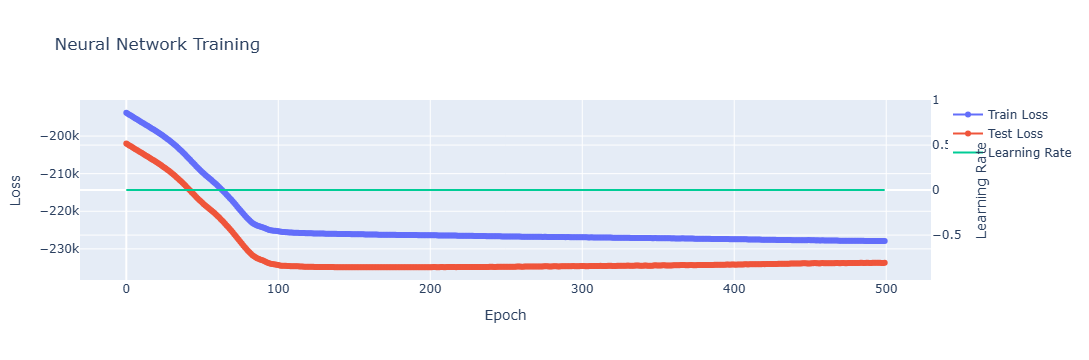

In [32]:
model.fit(
    X=X_train,
    y=y_train,
    weights=weights_train,
    X_test=X_test,
    y_test=y_test,
    weights_test=weights_test,
    epochs=500,
    lr=0.001,
    dropout=0.0,
    weight_decay=0,
    seed=42,
)

## Predict

In [33]:
predictions = model.predict(X)

In [34]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

 2026-01-19 14:34:43 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_neural] 
 2026-01-19 14:34:43 | morai.experience.charters | INFO     | Binning feature: [duration] with 8 bins 


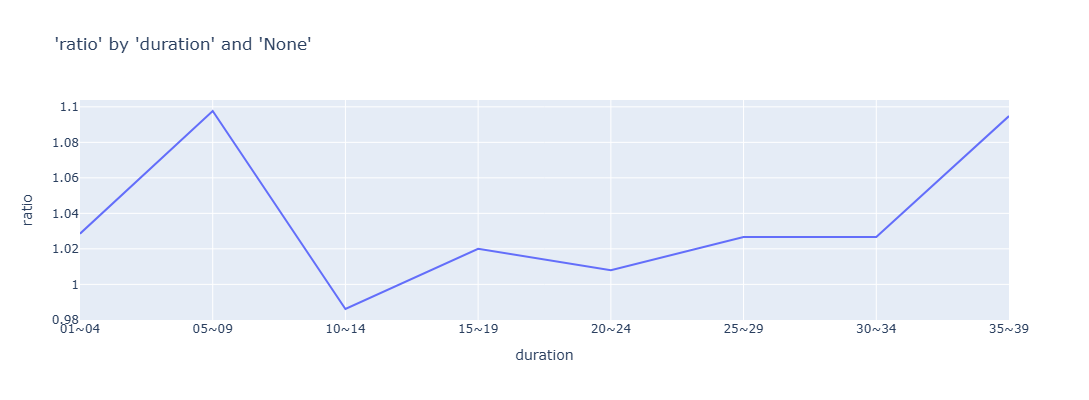

In [35]:
charters.chart(
    df=model_data,
    x_axis="duration",
    y_axis="ratio",
    numerator="death_claim_amount",
    denominator="exp_amt_neural",
    x_bins=8,
    type="line",
)

 2026-01-19 14:34:44 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


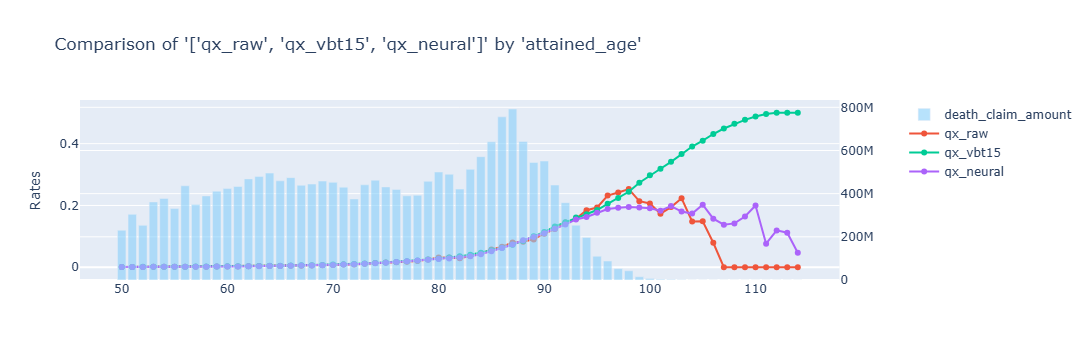

In [36]:
charters.compare_rates(
    model_data,
    x_axis="attained_age",
    rates=["qx_raw", "qx_vbt15", "qx_neural"],
    weights=["amount_exposed"],
    secondary="death_claim_amount",
    y_log=False,
)

# Analysis

## Prediction Analysis

### Train/Test Ratios

 2026-01-19 14:36:13 | morai.experience.charters | INFO     | Creating '9' target plots. 


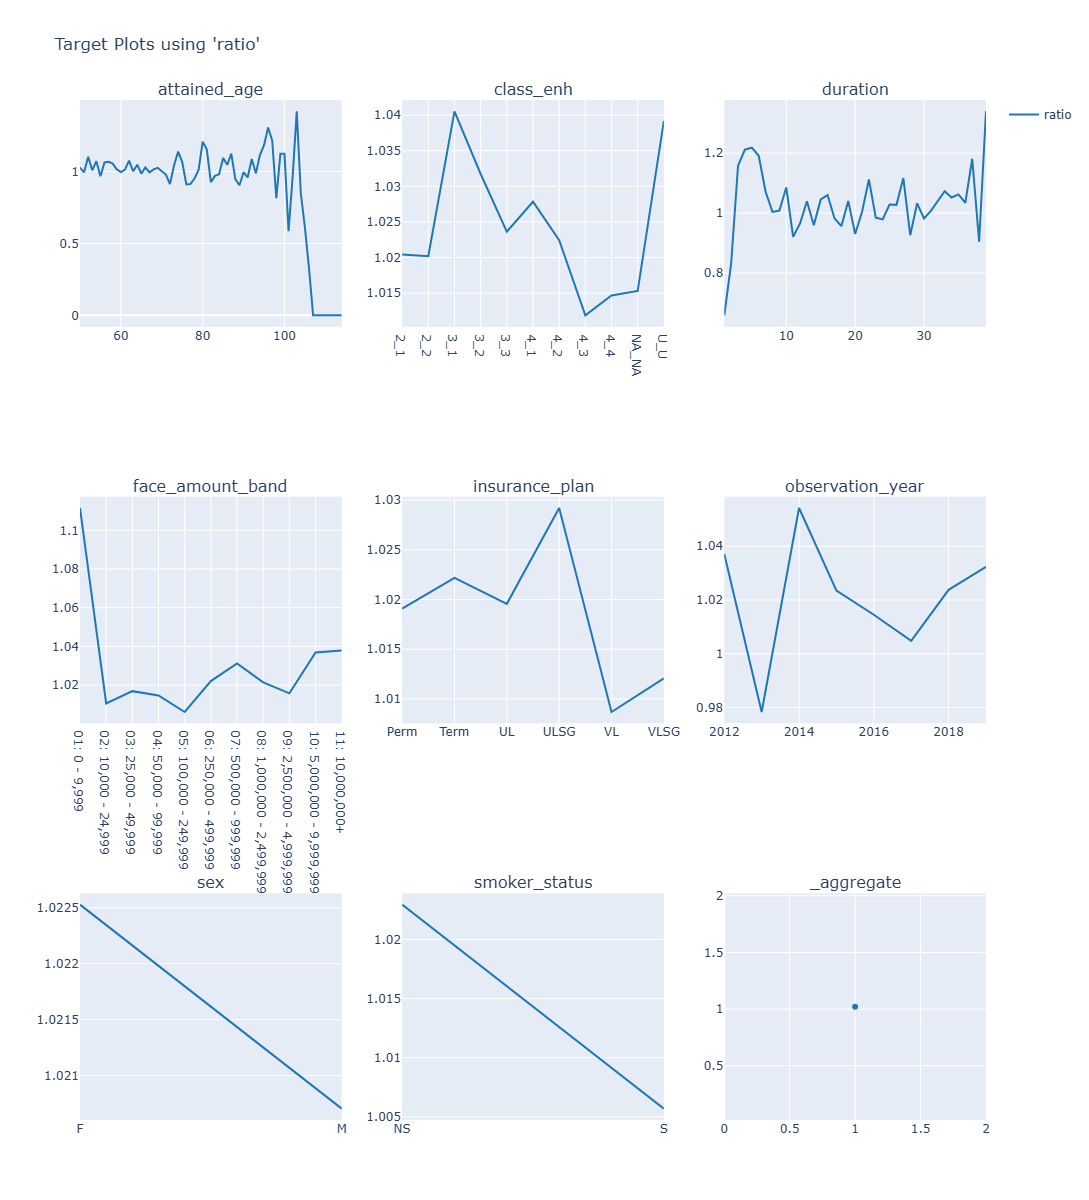

In [39]:
# train
charters.target(
    df=model_data.loc[X_train.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=["exp_amt_neural"],
).show()

 2026-01-19 14:34:46 | morai.experience.charters | INFO     | Creating '9' target plots. 


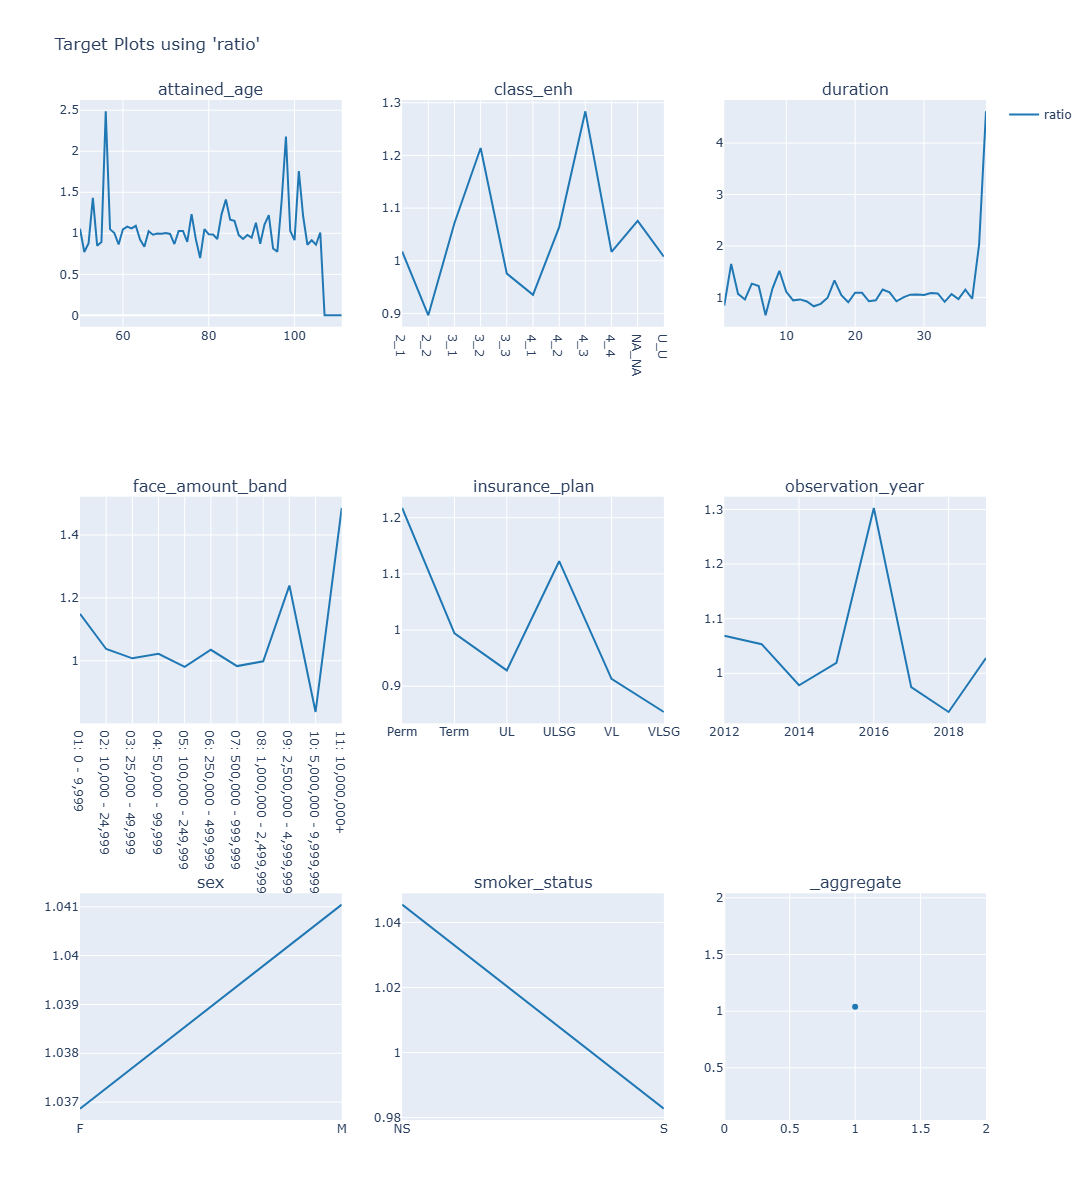

In [38]:
# test set
charters.target(
    df=model_data.loc[X_test.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=["exp_amt_neural"],
).show()

### PDP

 2026-01-18 12:03:19 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2026-01-18 12:03:19 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-01-18 12:03:19 | morai.experience.charters | INFO     | x_axis: [duration] type: [standardized] center: [global] 
 2026-01-18 12:03:19 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [passthrough] 
 2026-01-18 12:03:19 | morai.experience.charters | INFO     | Creating 234 predictions. 


Processing:   0%|          | 0/234 [00:00<?, ?combo/s]

 2026-01-18 12:06:06 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


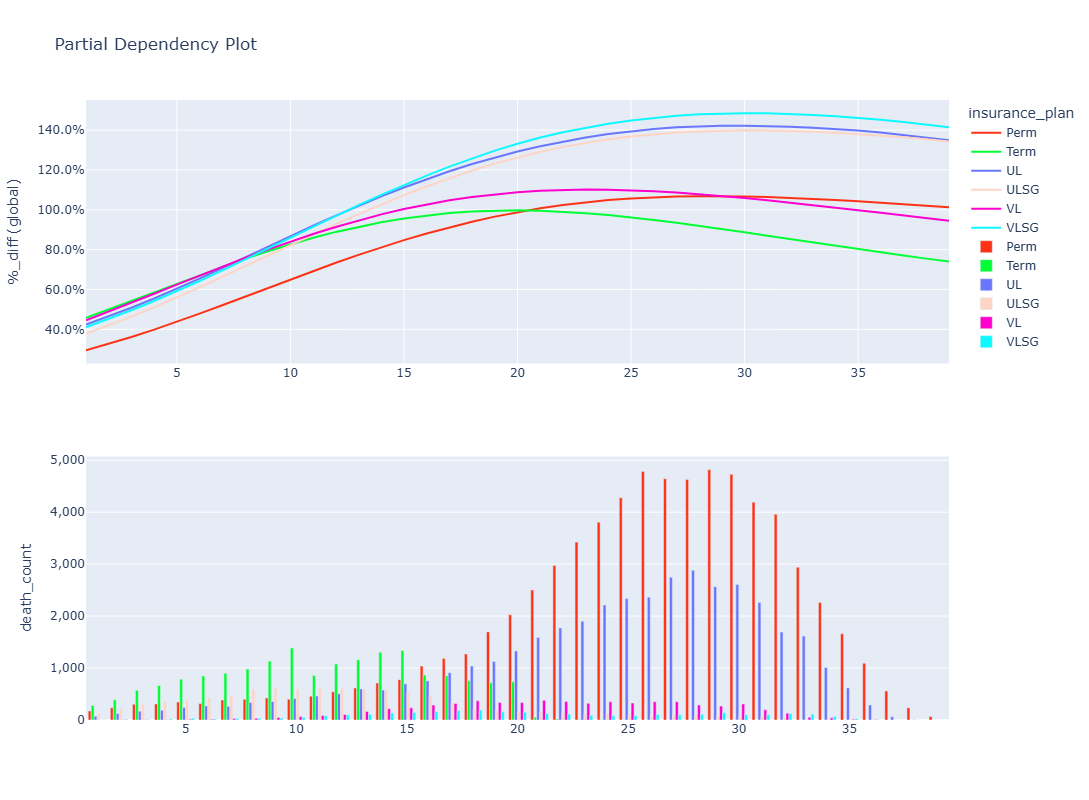

In [228]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="duration",
    line_color="insurance_plan",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

 2025-11-13 20:38:13 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2025-11-13 20:38:14 | morai.experience.charters | INFO     | x_axis: [duration] type: [standardized] center: [global] 
 2025-11-13 20:38:14 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [passthrough] 
 2025-11-13 20:38:14 | morai.experience.charters | INFO     | Creating 234 predictions. 


Processing:   0%|          | 0/234 [00:00<?, ?combo/s]

 2025-11-13 20:42:47 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


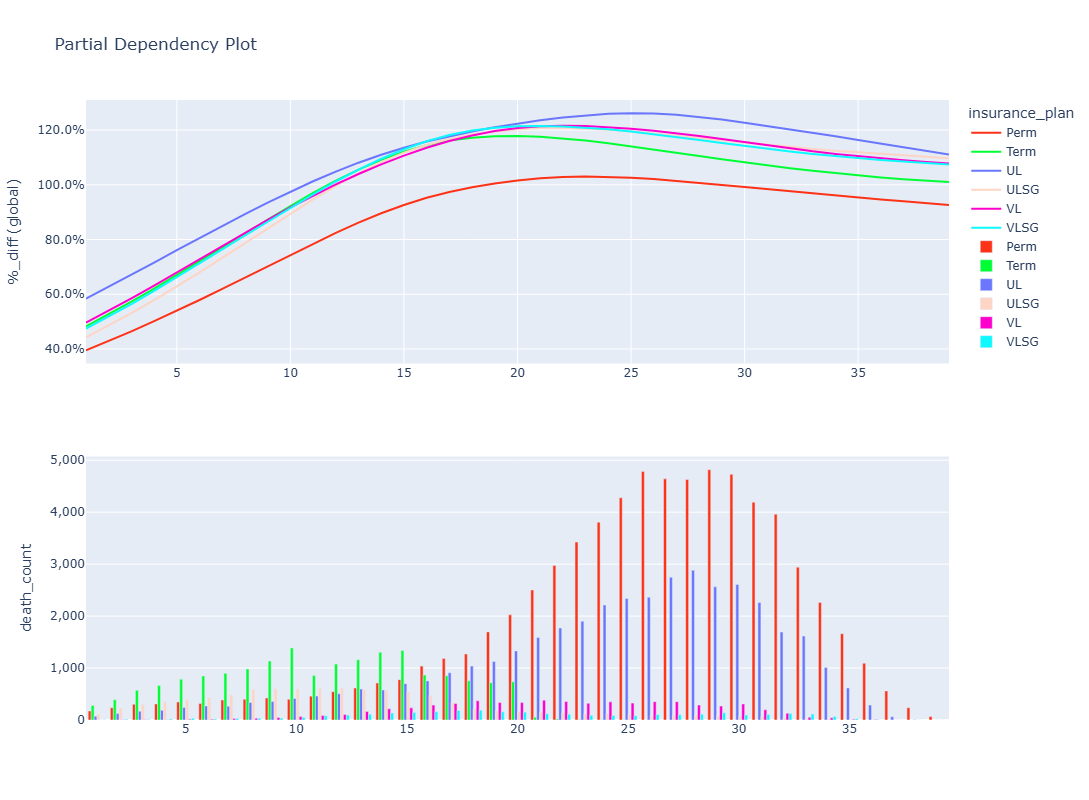

In [34]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="duration",
    line_color="insurance_plan",
    # weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

 2026-01-19 15:30:48 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2026-01-19 15:30:48 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-01-19 15:30:48 | morai.experience.charters | INFO     | x_axis: [attained_age] type: [spline] center: [per_x] 
 2026-01-19 15:30:48 | morai.experience.charters | INFO     | Line feature: [class_enh] type: [ohe] 
 2026-01-19 15:30:48 | morai.experience.charters | INFO     | Creating 200 predictions. 


Processing:   0%|          | 0/200 [00:00<?, ?combo/s]

 2026-01-19 15:31:01 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


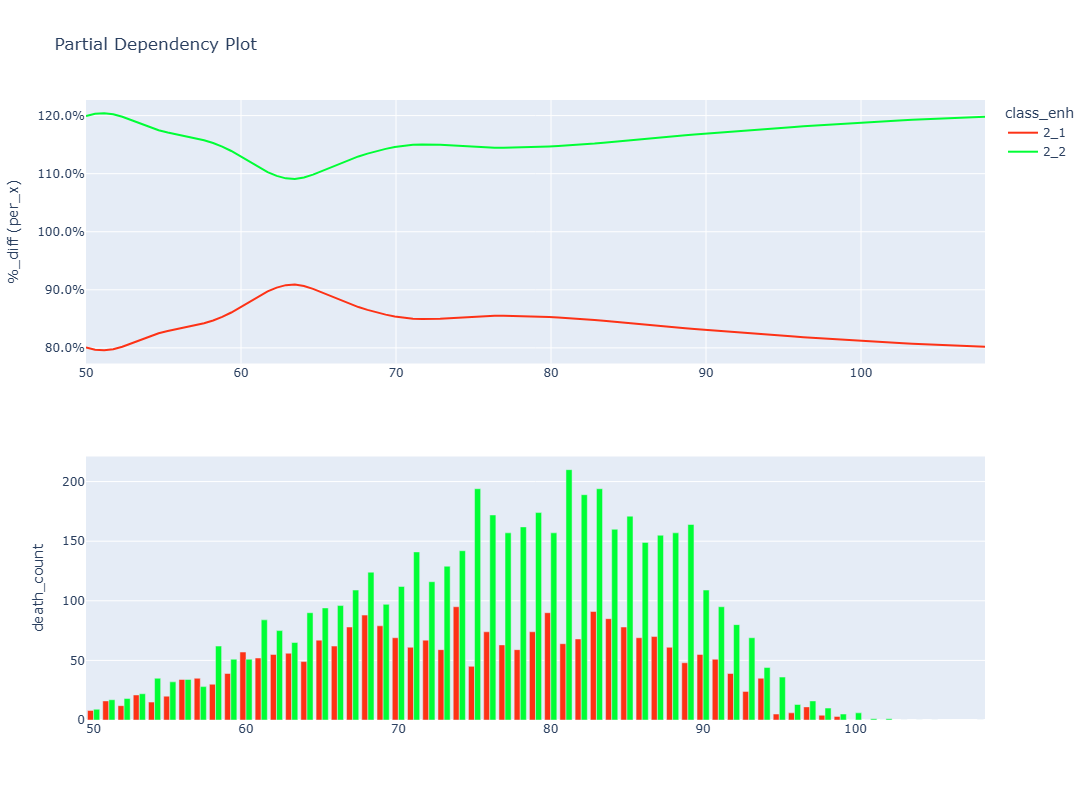

In [88]:
md_encoded["attained_age"] = model_data["attained_age"]
md_encoded["class_enh"] = model_data["class_enh"]
md_encoded["death_count"] = model_data["death_count"]

charters.pdp(
    model=model,
    df=md_encoded(md_encoded["class_enh"].isin(["2_1", "2_2"]))
    & (md_encoded["insurance_plan_UL"] == 1),
    x_axis="attained_age",
    line_color="class_enh",
    weight="amount_exposed",
    mapping=mapping,
    spline_dict=spline_dict,
    secondary="death_count",
    center="per_x",
    display=True,
)

## SHAP Analysis

SHAP (SHapley Additive exPlanations) is helpful in understanding the model predictions. It should be used as an additive test, because it will not provide information on how accurate the model is.

In [229]:
Shap = neural.Shap(model=model, background_df=X_train, n_samples=100, seed=42)

 2026-01-18 12:06:07 | morai.models.neural | INFO     | creating SHAP KernelExplainer with `100` background samples and a seed of `42` 


In [230]:
shap_values = Shap.compute_values(explain_df=X_test, n_samples=100, seed=42)

 2026-01-18 12:06:07 | morai.models.neural | INFO     | calculating shap_values with `100` explainer samples and a seed of `42` 


  0%|          | 0/100 [00:00<?, ?it/s]

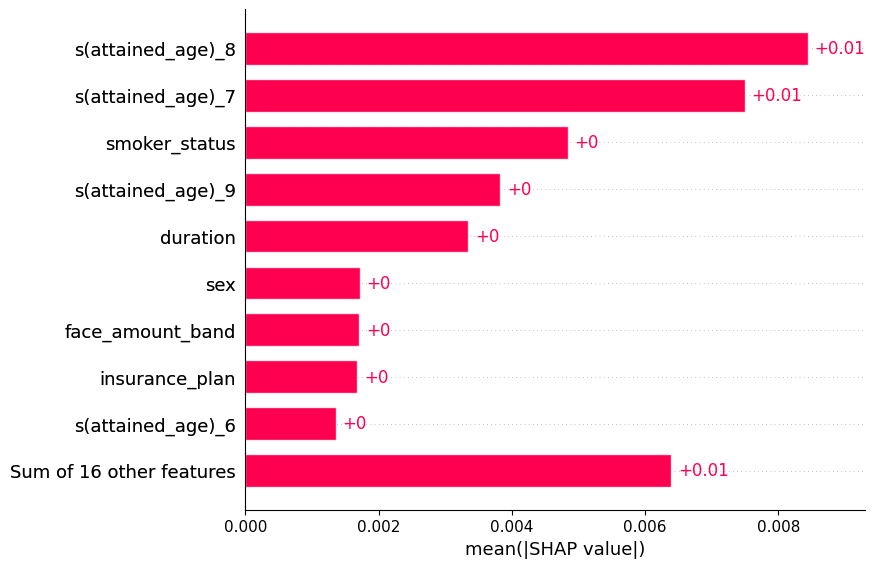

In [231]:
shap.plots.bar(Shap.shap_values)

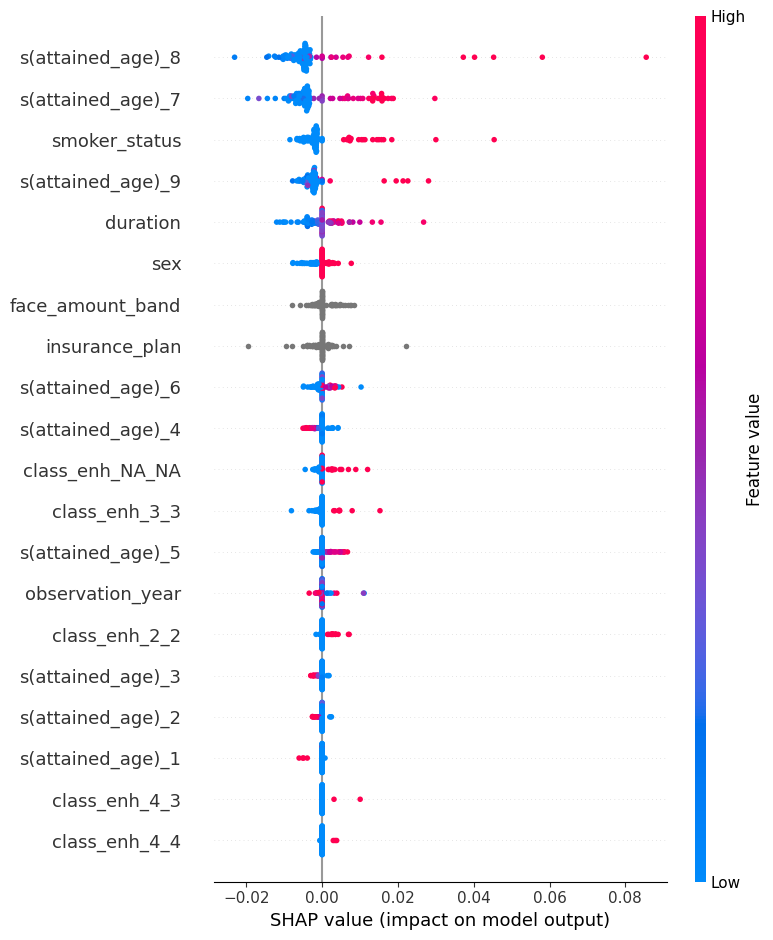

In [232]:
shap.summary_plot(Shap.shap_values, Shap.sample_explain_df)

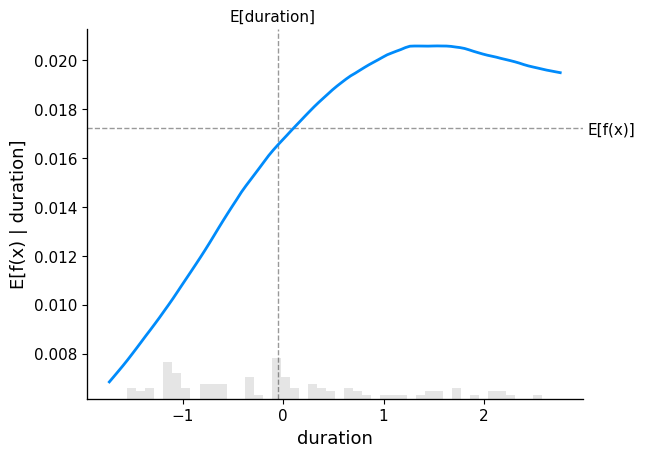

In [233]:
shap.partial_dependence_plot(
    "duration",
    model.predict,
    Shap.sample_explain_df,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

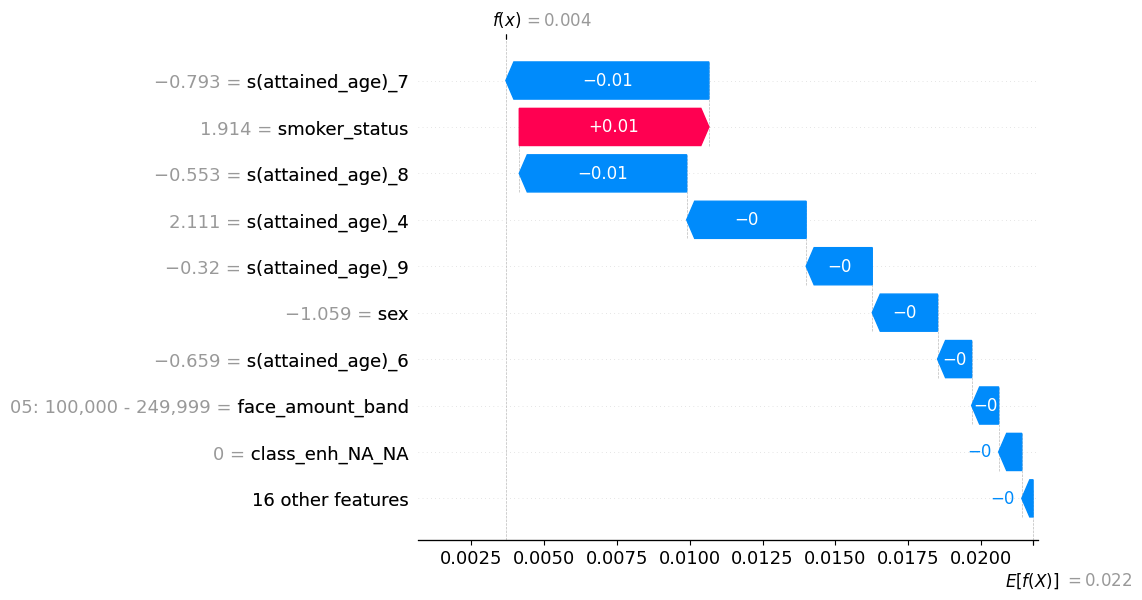

In [234]:
shap.plots.waterfall(Shap.shap_values[0])

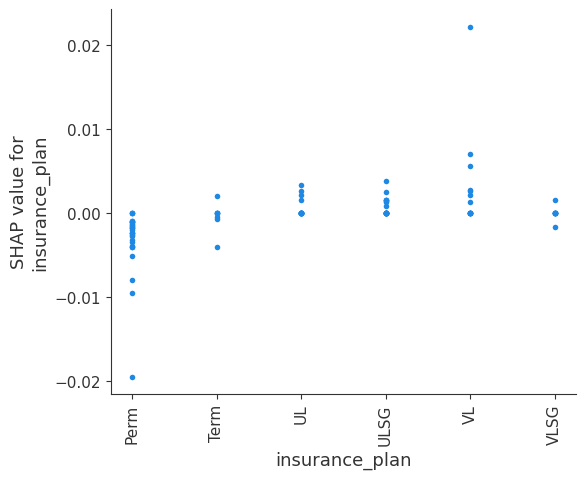

In [235]:
shap.dependence_plot(
    "insurance_plan",
    Shap.shap_values.values,
    Shap.sample_explain_df,
    interaction_index=None,
)

## Embedding Analysis

The column `insurance_plan` was embedded to have the neural network learn the relationships of this column naturally instead of using an encoding such as ordinal or nominal. To understand the embeddings better, the weights of the embeddings were extracted and then analyzed using cosine similarity, pca, or t-sne. As seen the embeddings are 4 dimensions.

In [40]:
model.embedding_get_weights("face_amount_band")

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5
__UNK__,-0.29,0.18,0.12,-0.15,0.34,0.39
"02: 10,000 - 24,999",-0.44,-0.44,0.78,-0.50,0.13,-0.70
"09: 2,500,000 - 4,999,999",-0.17,-0.05,-0.19,-0.53,-0.16,-0.66
"10: 5,000,000 - 9,999,999",-0.45,0.06,-0.45,-0.35,0.83,0.27
"06: 250,000 - 499,999",0.23,-0.69,-0.28,-0.16,0.13,-0.28
"08: 1,000,000 - 2,499,999",-0.38,-0.38,-0.15,-0.28,-0.04,-0.75
"03: 25,000 - 49,999",-0.47,-0.59,0.17,-0.39,0.50,-0.01
"01: 0 - 9,999",0.80,-0.12,-0.12,-0.03,0.26,-0.61
"04: 50,000 - 99,999",-0.23,-0.47,0.19,-0.30,0.21,-0.26
"05: 100,000 - 249,999",0.53,-0.74,-0.12,-0.18,0.30,0.24


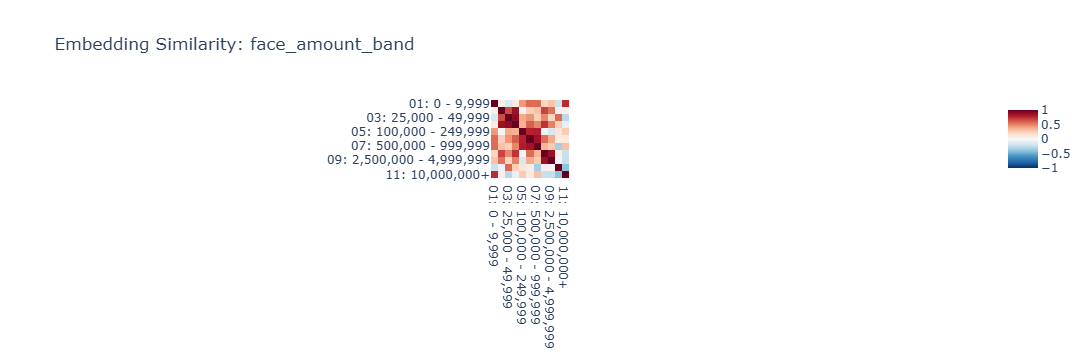

In [41]:
model.embedding_plot_similarity("face_amount_band")

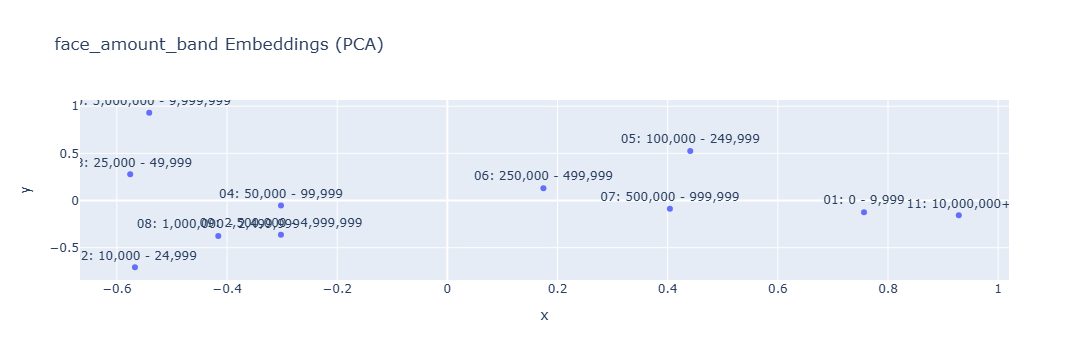

In [42]:
model.embedding_plot_2d("face_amount_band", method="pca")

 2026-01-19 14:37:29 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2026-01-19 14:37:29 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-01-19 14:37:29 | morai.experience.charters | INFO     | x_axis: [face_amount_band] type: [passthrough] center: [global] 
 2026-01-19 14:37:29 | morai.experience.charters | INFO     | Creating 11 predictions. 


Processing:   0%|          | 0/11 [00:00<?, ?combo/s]

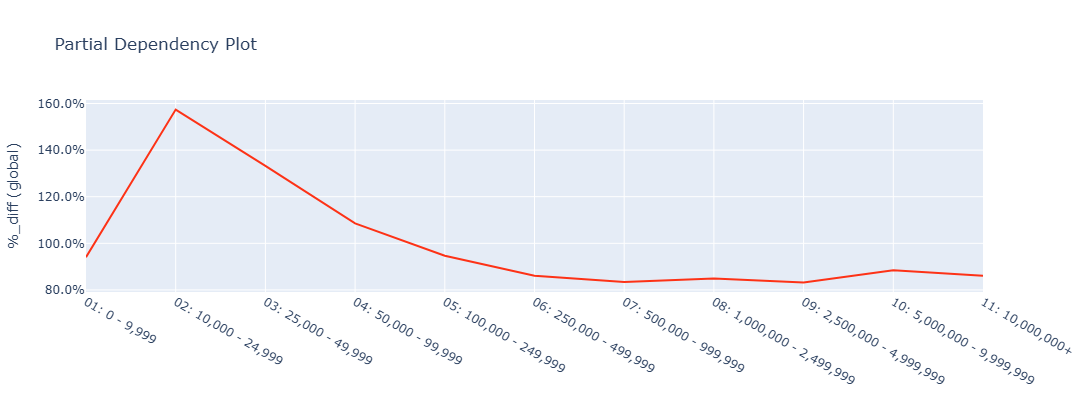

In [43]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="face_amount_band",
    weight="amount_exposed",
    mapping=mapping,
    display=True,
)

# Reload

In [30]:
import importlib

In [45]:
importlib.reload(neural)

<module 'morai.models.neural' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\neural.py'>